# Perceptron on Brainvita (From Scratch)

This notebook uses the custom `rice_ml.supervised_learning.Perceptron` to classify Brainvita board states as high mobility or low mobility.

Target:

- Class 1: `num_legal_moves >= 3`
- Class 0: `num_legal_moves < 3`

The perceptron is the simplest linear classifier in this notebook set. It does not estimate probabilities like logistic regression and it cannot bend its decision boundary like a tree or MLP. Its value is that every mistake triggers a clear update rule, so it is a transparent bridge between linear models and neural networks.

## Learning Objectives

1. Explain the perceptron decision rule and mistake-driven update.
2. Build the same leakage-safe Brainvita classification dataset used by logistic regression.
3. Compare multiple learning-rate and iteration settings using F1.
4. Inspect convergence through the mistake count per epoch.
5. Interpret margins and coefficients while acknowledging linear-separability limits.


## Dataset and Target

The notebook uses the same curated Brainvita feature set as the logistic regression and MLP notebooks. The label is high mobility: class 1 when `num_legal_moves >= 3`, class 0 otherwise.

This target is intentionally not a win/loss label. It asks whether the current state has several immediate options. Because the positive class is smaller than the negative class, F1 and recall are important alongside accuracy.

## 1. Mathematical Foundation

Decision rule:

$$
\hat{y} = \mathrm{sign}(w^T x + b)
$$

Update on a mistake:

$$
w \leftarrow w + \eta yx, \quad b \leftarrow b + \eta y
$$

Perceptron converges in finite steps only when training data is linearly separable.


## 2. Why Perceptron Still Matters

- simplest online linear classifier
- interpretable weight vector
- foundational bridge to MLPs and margin-based methods


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root(start='.'):
    p = Path(start).resolve()
    for q in [p, *p.parents]:
        if (q / 'src' / 'rice_ml').exists() and (q / 'data' / 'brainvita_dataset.csv').exists():
            return q
    raise FileNotFoundError('Could not locate repository root with src/rice_ml and data/brainvita_dataset.csv')

ROOT = find_repo_root('.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

DATA_PATH = ROOT / 'data' / 'brainvita_dataset.csv'

preferred_features = ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']

from rice_ml.supervised_learning import Perceptron

In [2]:
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    header = f.readline().strip().split(',')

exclude_cols = {
    'num_legal_moves',
    'board_state',
    'best_move_r1', 'best_move_c1', 'best_move_r2', 'best_move_c2',
    'worst_move_r1', 'worst_move_c1', 'worst_move_r2', 'worst_move_c2',
}

raw_feature_cols = [c for c in header if c not in exclude_cols]
selected_cols = raw_feature_cols + ['num_legal_moves']
selected_idx = [header.index(c) for c in selected_cols]
arr = np.loadtxt(DATA_PATH, delimiter=',', skiprows=1, usecols=selected_idx, dtype=float)

X_raw = arr[:, :-1]
y_reg = arr[:, -1]
y_bin = (y_reg >= 3.0).astype(int)

feature_cols = [c for c in preferred_features if c in raw_feature_cols]
keep_idx = [raw_feature_cols.index(c) for c in feature_cols]
X = X_raw[:, keep_idx]

print('Rows:', f'{X.shape[0]:,}')
print('Features:', X.shape[1])
print('Positive class rate (num_legal_moves >= 3):', round(float(y_bin.mean()), 4))
print('Feature set:', feature_cols)


Rows: 238,486
Features: 15
Positive class rate (num_legal_moves >= 3): 0.2918
Feature set: ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']


## 3. Split and Scale

The perceptron learns through gradient-like mistake updates, so feature scale affects how large each coordinate update is. We split first, then standardize with training-set statistics only. This keeps the test set unseen during preprocessing.

In [3]:
rng = np.random.default_rng(42)
idx = np.arange(X.shape[0])
rng.shuffle(idx)
split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y_bin[train_idx], y_bin[test_idx]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma_safe = np.where(sigma < 1e-12, 1.0, sigma)

X_train = (X_train_raw - mu) / sigma_safe
X_test = (X_test_raw - mu) / sigma_safe

print('Train samples:', f'{X_train.shape[0]:,}', '| Test samples:', f'{X_test.shape[0]:,}')


Train samples: 190,788 | Test samples: 47,698


In [4]:
def baseline_class_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    acc = float(np.mean(y_true == y_pred))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {'acc': acc, 'precision': precision, 'recall': recall, 'f1': f1}

majority_class = int(np.bincount(y_train).argmax())
majority_pred = np.full_like(y_test, majority_class)
majority_metrics = baseline_class_metrics(y_test, majority_pred)
print('Majority baseline (test):', {k: round(v, 4) for k, v in majority_metrics.items()})


Majority baseline (test): {'acc': 0.7089, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


## 4. Hyperparameter Sweep

We sweep learning rate and maximum iterations because the perceptron update can oscillate when the data is not perfectly linearly separable. The selected model is chosen by test F1 so the positive high-mobility class is not ignored.

In [5]:
def class_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    acc = float(np.mean(y_true == y_pred))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {'acc': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': np.array([[tn, fp], [fn, tp]])}

configs = [
    {'learning_rate': 0.01, 'max_iter': 80},
    {'learning_rate': 0.05, 'max_iter': 120},
    {'learning_rate': 0.1, 'max_iter': 200},
    {'learning_rate': 0.2, 'max_iter': 250},
]

results = []
models = []
for cfg in configs:
    m = Perceptron(learning_rate=cfg['learning_rate'], max_iter=cfg['max_iter'], fit_intercept=True, shuffle=True, random_state=42)
    m.fit(X_train, y_train)
    met = class_metrics(y_test, m.predict(X_test))
    results.append((cfg, met, m))
    models.append(m)

print('Sweep results (test)')
print('-' * 84)
print(f"{'lr':>8} {'max_iter':>10} {'acc':>10} {'precision':>10} {'recall':>10} {'f1':>10}")
print('-' * 84)
for cfg, met, _ in results:
    print(f"{cfg['learning_rate']:>8.3f} {cfg['max_iter']:>10d} {met['acc']:>10.4f} {met['precision']:>10.4f} {met['recall']:>10.4f} {met['f1']:>10.4f}")
print('-' * 84)

best_cfg, best_met, best_model = sorted(results, key=lambda t: t[1]['f1'], reverse=True)[0]
print('Selected config:', best_cfg)


Sweep results (test)
------------------------------------------------------------------------------------
      lr   max_iter        acc  precision     recall         f1
------------------------------------------------------------------------------------
   0.010         80     0.9826     0.9964     0.9438     0.9694
   0.050        120     0.9802     0.9496     0.9841     0.9665
   0.100        200     0.9890     0.9883     0.9736     0.9809
   0.200        250     0.9876     0.9920     0.9651     0.9784
------------------------------------------------------------------------------------
Selected config: {'learning_rate': 0.1, 'max_iter': 200}


## 5. Final Model Evaluation

The final evaluation compares train and test metrics. Close train/test scores suggest that the linear separator is stable. A large gap would mean the selected perceptron is memorizing training patterns rather than learning a reusable boundary.

Train metrics: {'acc': 0.9897, 'precision': 0.9884, 'recall': 0.9763, 'f1': 0.9823}
Test metrics : {'acc': 0.989, 'precision': 0.9883, 'recall': 0.9736, 'f1': 0.9809}


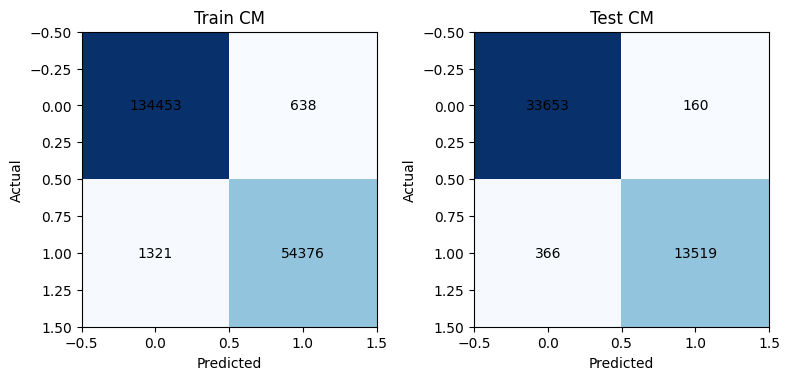

In [6]:
def class_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    acc = float(np.mean(y_true == y_pred))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {'acc': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': np.array([[tn, fp], [fn, tp]])}

model = best_model
train_met = class_metrics(y_train, model.predict(X_train))
test_met = class_metrics(y_test, model.predict(X_test))

print('Train metrics:', {k: round(v, 4) for k, v in train_met.items() if k != 'cm'})
print('Test metrics :', {k: round(v, 4) for k, v in test_met.items() if k != 'cm'})

fig, ax = plt.subplots(1, 2, figsize=(8, 3.8))
for i, (cm, title) in enumerate([(train_met['cm'], 'Train CM'), (test_met['cm'], 'Test CM')]):
    im = ax[i].imshow(cm, cmap='Blues')
    ax[i].set_title(title)
    ax[i].set_xlabel('Predicted')
    ax[i].set_ylabel('Actual')
    for r in range(2):
        for c in range(2):
            ax[i].text(c, r, int(cm[r, c]), ha='center', va='center', color='black')
plt.tight_layout()
plt.show()


## 6. Convergence Diagnostics

The perceptron stores the number of mistakes in each epoch. A fast drop toward zero means the linear boundary is close to separating the training data. Persistent mistakes mean the Brainvita classes overlap in this feature space, which is expected for a game-state mobility label.

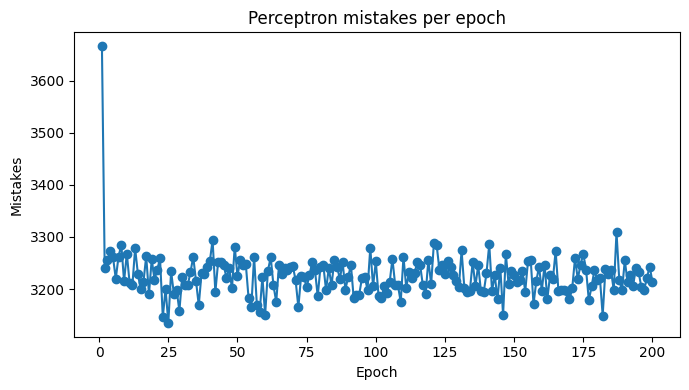

Epochs executed: 200
Final mistakes  : 3213


In [7]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(model.errors_) + 1), model.errors_, marker='o', linewidth=1.5)
plt.title('Perceptron mistakes per epoch')
plt.xlabel('Epoch')
plt.ylabel('Mistakes')
plt.tight_layout()
plt.show()

print('Epochs executed:', model.n_iter_)
print('Final mistakes  :', model.errors_[-1])


## 7. Margin Analysis

The margin is the signed distance-like score `w^T x + b`. Large positive margins indicate confident high-mobility predictions; large negative margins indicate confident low-mobility predictions. Points near zero are the ambiguous board states where a small feature change could flip the class.

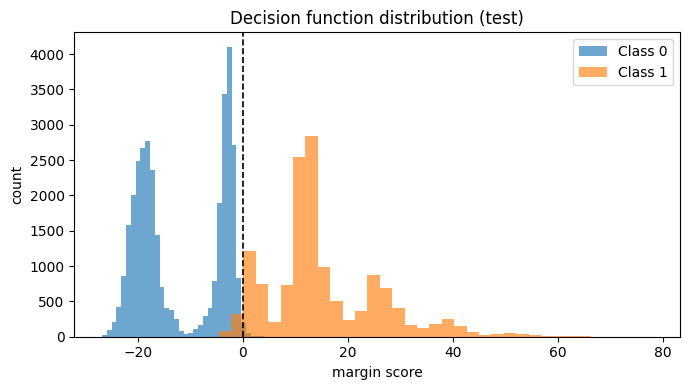

In [8]:
scores = model.decision_function(X_test)

plt.figure(figsize=(7, 4))
plt.hist(scores[y_test == 0], bins=35, alpha=0.65, label='Class 0')
plt.hist(scores[y_test == 1], bins=35, alpha=0.65, label='Class 1')
plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
plt.title('Decision function distribution (test)')
plt.xlabel('margin score')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Coefficient Interpretation

Because the features are standardized, coefficient magnitudes are comparable. A large positive coefficient pushes the model toward high mobility; a large negative coefficient pushes it toward low mobility. As with linear regression, these are associations under correlated board features, not causal effects.

In [9]:
abs_coef = np.abs(model.coef_)
order = np.argsort(abs_coef)[::-1]
print('Top 12 perceptron coefficients by |value|')
print('-' * 76)
print(f"{'Rank':<6}{'Feature':<28}{'Coefficient':>18}{'|Coefficient|':>18}")
print('-' * 76)
for rank, i in enumerate(order[:12], start=1):
    print(f"{rank:<6}{feature_cols[i]:<28}{model.coef_[i]:>18.6f}{abs_coef[i]:>18.6f}")
print('-' * 76)


Top 12 perceptron coefficients by |value|
----------------------------------------------------------------------------
Rank  Feature                            Coefficient     |Coefficient|
----------------------------------------------------------------------------
1     jumpable_pegs                        11.958899         11.958899
2     mobility_ratio                        3.825755          3.825755
3     avg_adjacent_pegs                     2.997698          2.997698
4     peg_ratio                             2.357215          2.357215
5     largest_cluster                      -1.777971          1.777971
6     avg_adjacent_empty                    1.277531          1.277531
7     board_cols                            1.076437          1.076437
8     max_adjacent_empty                    0.845078          0.845078
9     board_rows                            0.537220          0.537220
10    num_clusters                          0.321676          0.321676
11    min_pegs_reachabl

## 9. Conclusion

The perceptron is a strong teaching baseline for Brainvita classification. It shows how a linear boundary can be learned through mistake-driven updates, and the convergence plot makes the training process visible.

Its main limitation is also clear: it only learns one linear separator and does not produce calibrated probabilities. Logistic regression adds probabilities and smoother optimization, while the MLP adds nonlinear hidden layers.

Perceptron works well as a fast linear baseline on this binary mobility framing, but its linear decision boundary limits expressiveness for complex Brainvita dynamics.
